## Objectif

Ce notebook réalise l'alignement par préférences du modèle SFT LoRA.

Le modèle de départ est le meilleur checkpoint SFT sélectionné après évaluation sur le jeu de test :

`outputs/qwen3-sft-3epochs/checkpoint-4762`

Le DPO utilise les paires préférentielles du dataset `dpo_train.jsonl` :

- `prompt` : question ou cas clinique ;
- `chosen_response` : réponse préférée ;
- `rejected_response` : réponse moins pertinente.

L'objectif est d'aligner le modèle vers des réponses médicales plus pertinentes et plus prudentes, en apprenant à favoriser les réponses choisies par rapport aux réponses rejetées.

In [2]:
import torch

print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

CUDA disponible : True
GPU : Tesla T4


In [3]:
!pip install -q transformers datasets peft trl accelerate safetensors pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.1 MB/s eta 0:00:00


In [4]:
from google.colab import files

uploaded = files.upload()

Saving dpo_train.jsonl to dpo_train.jsonl
Saving dpo_validation.jsonl to dpo_validation.jsonl


In [5]:
from google.colab import files
uploaded = files.upload()

Saving checkpoint-4762.zip to checkpoint-4762.zip


In [7]:
!unzip -q checkpoint-4762.zip -d /content/

replace /content/checkpoint-4762/adapter_config.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [19]:
import os

SFT_CHECKPOINT_DIR = "/content/checkpoint-4762"
DPO_TRAIN_FILE = "/content/dpo_train.jsonl"
DPO_VALIDATION_FILE = "/content/dpo_validation.jsonl"
OUTPUT_DIR = "/content/qwen3-dpo"

SEED = 42
MAX_LENGTH = 1024
MAX_PROMPT_LENGTH = 512

paths_to_check = [
    SFT_CHECKPOINT_DIR,
    DPO_TRAIN_FILE,
    DPO_VALIDATION_FILE,
]

for path in paths_to_check:
    print(path, "->", os.path.exists(path))

print("MAX_LENGTH :", MAX_LENGTH)
print("MAX_PROMPT_LENGTH :", MAX_PROMPT_LENGTH)

/content/checkpoint-4762 -> True
/content/dpo_train.jsonl -> True
/content/dpo_validation.jsonl -> True
MAX_LENGTH : 1024
MAX_PROMPT_LENGTH : 512


In [9]:
print(os.listdir(SFT_CHECKPOINT_DIR))

['tokenizer.json', 'scheduler.pt', 'tokenizer_config.json', 'optimizer.pt', 'adapter_model.safetensors', 'scaler.pt', 'trainer_state.json', 'rng_state.pth', 'README.md', 'chat_template.jinja', 'training_args.bin', 'adapter_config.json']


In [10]:
import torch
import pandas as pd

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from trl import DPOTrainer, DPOConfig

In [11]:
import transformers
import trl
import peft

print("transformers :", transformers.__version__)
print("trl :", trl.__version__)
print("peft :", peft.__version__)
print("CUDA :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

transformers : 5.9.0
trl : 1.5.1
peft : 0.19.1
CUDA : True
GPU : Tesla T4


## Chargement du dataset DPO

Les fichiers DPO contiennent des paires préférentielles :

- `prompt` : question ou cas clinique ;
- `chosen_response` : réponse préférée ;
- `rejected_response` : réponse moins pertinente.

Ces paires sont utilisées pour apprendre au modèle à favoriser les réponses de meilleure qualité.

In [12]:
dpo_train = load_dataset(
    "json",
    data_files=DPO_TRAIN_FILE,
    split="train"
)

dpo_val = load_dataset(
    "json",
    data_files=DPO_VALIDATION_FILE,
    split="train"
)

print("DPO train :", len(dpo_train))
print("DPO validation :", len(dpo_val))
print(dpo_train[0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

DPO train : 1600
DPO validation : 200
{'prompt': "Delve into the current challenges faced in the implementation of stem cell therapy for neurodegenerative disorders, emphasizing not only the enhancement of survival rates for the transplanted cells but also the intricacies involved in their integration and functional synchronization within the existing neural networks of the host's central nervous system.", 'chosen_response': "Stem cell therapy offers a promising avenue for treating neurodegenerative disorders, which are characterized by the progressive loss of structure or function of neurons, including diseases such as Alzheimer's, Parkinson's, and Huntington's. However, several significant challenges must be addressed to make stem cell therapy a viable and effective treatment for these conditions. These challenges include:\n\n1. **Cell Survival:** After transplantation, a significant number of stem cells do not survive in the host brain due to the hostile environment of the injured o

## Préparation du format DPO

Le dataset est adapté au format attendu par `DPOTrainer`.

Les colonnes sont renommées :
- `chosen_response` devient `chosen` ;
- `rejected_response` devient `rejected`.

Le prompt est conservé tel quel.

In [13]:
def format_for_dpo(example):
    return {
        "prompt": example["prompt"].strip(),
        "chosen": example["chosen_response"].strip(),
        "rejected": example["rejected_response"].strip(),
    }

dpo_train = dpo_train.map(
    format_for_dpo,
    remove_columns=dpo_train.column_names
)

dpo_val = dpo_val.map(
    format_for_dpo,
    remove_columns=dpo_val.column_names
)

print(dpo_train[0])
print(dpo_val[0])

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

{'prompt': "Delve into the current challenges faced in the implementation of stem cell therapy for neurodegenerative disorders, emphasizing not only the enhancement of survival rates for the transplanted cells but also the intricacies involved in their integration and functional synchronization within the existing neural networks of the host's central nervous system.", 'chosen': "Stem cell therapy offers a promising avenue for treating neurodegenerative disorders, which are characterized by the progressive loss of structure or function of neurons, including diseases such as Alzheimer's, Parkinson's, and Huntington's. However, several significant challenges must be addressed to make stem cell therapy a viable and effective treatment for these conditions. These challenges include:\n\n1. **Cell Survival:** After transplantation, a significant number of stem cells do not survive in the host brain due to the hostile environment of the injured or diseased tissue. This environment can be char

## Chargement du tokenizer

Le tokenizer sauvegardé avec le checkpoint SFT est utilisé afin de conserver la même configuration que pendant le fine-tuning supervisé.

In [14]:
tokenizer = AutoTokenizer.from_pretrained(
    SFT_CHECKPOINT_DIR,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer chargé")
print("Pad token :", tokenizer.pad_token)
print("EOS token :", tokenizer.eos_token)

Tokenizer chargé
Pad token : <|endoftext|>
EOS token : <|endoftext|>


## Chargement du modèle SFT

Le DPO part du meilleur checkpoint SFT sélectionné lors de l'évaluation sur le jeu de test.

Le modèle de base est chargé, puis les poids LoRA du checkpoint SFT sont appliqués.

In [16]:
!pip install -q --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.2 MB/s eta 0:00:00


In [17]:
BASE_MODEL_NAME = "Qwen/Qwen3-1.7B-Base"

device = "cuda" if torch.cuda.is_available() else "cpu"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    trust_remote_code=True,
    low_cpu_mem_usage=False,
)

model = PeftModel.from_pretrained(
    base_model,
    SFT_CHECKPOINT_DIR,
    is_trainable=True,
)

model.to(device)
model.config.use_cache = False
model.gradient_checkpointing_enable()

model.print_trainable_parameters()
print("Modèle SFT chargé pour DPO")
print("Device principal :", next(model.parameters()).device)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

trainable params: 1,605,632 || all params: 1,722,180,608 || trainable%: 0.0932
Modèle SFT chargé pour DPO
Device principal : cuda:0


## Modèle de référence DPO

Le DPO compare le modèle entraîné à un modèle de référence afin d'éviter des dérives trop importantes.

Avec PEFT/LoRA, `DPOTrainer` peut utiliser le modèle chargé comme base et gérer la référence de manière implicite.  
Cette configuration limite la mémoire utilisée sur GPU.

## Configuration de l'entraînement DPO

La configuration DPO est volontairement prudente afin de tenir sur un GPU T4 Colab.

Le run utilise un batch size réduit, le gradient checkpointing et des sauvegardes régulières.

In [23]:
dpo_args = DPOConfig(
    output_dir=OUTPUT_DIR,

    max_length=MAX_LENGTH,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,

    learning_rate=5e-5,
    num_train_epochs=1,

    beta=0.1,

    logging_steps=25,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=SEED,
    remove_unused_columns=False,
)

## Création du DPOTrainer

Le `DPOTrainer` orchestre l'entraînement par préférences.

Il reçoit :
- le modèle SFT LoRA à aligner ;
- le tokenizer ;
- le dataset DPO train ;
- le dataset DPO validation ;
- la configuration DPO.

In [24]:
dpo_trainer = DPOTrainer(
    model=model,
    args=dpo_args,
    processing_class=tokenizer,
    train_dataset=dpo_train,
    eval_dataset=dpo_val,
)

print("DPOTrainer créé")

Adding EOS to train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1600 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

DPOTrainer créé


## Lancement de l'entraînement DPO

L'entraînement DPO est lancé sur les paires préférentielles.

Ce run vise à valider l'étape d'alignement par préférences à partir du checkpoint SFT sélectionné.

In [25]:
dpo_train_result = dpo_trainer.train()

dpo_train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
200,0.477377,0.545721,0.954124,426821.000000,5.461308,5.609732,0.735728,0.461401,-0.503610,0.750000,0.965011,-413.589349,-324.167490
400,0.771016,0.560334,0.962382,875998.000000,5.316620,5.426783,0.734267,0.161223,-1.352502,0.785000,1.513726,-416.591121,-332.656407
600,0.478745,0.529720,0.953266,1313254.000000,5.228131,5.329547,0.734283,0.177402,-1.449546,0.805000,1.626947,-416.429339,-333.626844
800,0.530678,0.531719,0.963031,1751418.000000,5.238414,5.337520,0.733493,0.092805,-1.603174,0.810000,1.695979,-417.275304,-335.163123


TrainOutput(global_step=800, training_loss=0.5782943463325501, metrics={'train_runtime': 2923.9173, 'train_samples_per_second': 0.547, 'train_steps_per_second': 0.274, 'total_flos': 1.6325557143564288e+16, 'train_loss': 0.5782943463325501, 'epoch': 1.0})

In [26]:
dpo_eval_metrics = dpo_trainer.evaluate()
dpo_eval_metrics

Training Loss,Validation Loss,Step,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
0.530678,0.531719,800,0.963031,1751418.000000,5.238414,5.337520,0.733493,0.092805,-1.603174,0.810000,1.695979,-417.275304,-335.163123


{'eval_loss': 0.5317192673683167,
 'eval_entropy': 0.9630310386419296,
 'eval_num_tokens': 1751418.0,
 'eval_logits/chosen': 5.238414317420654,
 'eval_logits/rejected': 5.337519880757418,
 'eval_mean_token_accuracy': 0.7334928902983665,
 'eval_rewards/chosen': 0.09280505359638483,
 'eval_rewards/rejected': -1.6031736771413125,
 'eval_rewards/accuracies': 0.81,
 'eval_rewards/margins': 1.6959787325933575,
 'eval_logps/chosen': -417.2753043746948,
 'eval_logps/rejected': -335.16312313079834}

In [27]:
print("DPO train loss :", dpo_train_result.metrics["train_loss"])
print("DPO validation loss :", dpo_eval_metrics["eval_loss"])
print("Global step :", dpo_train_result.global_step)

DPO train loss : 0.5782943463325501
DPO validation loss : 0.5317192673683167
Global step : 800


## Sauvegarde du checkpoint DPO

Le modèle aligné par préférences est sauvegardé afin de conserver un checkpoint reproductible pour l'évaluation finale.

In [28]:
dpo_trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Checkpoint DPO sauvegardé dans :", OUTPUT_DIR)

Checkpoint DPO sauvegardé dans : /content/qwen3-dpo


## Suivi des métriques DPO

Les logs du `DPOTrainer` sont extraits afin de documenter l'évolution de la loss pendant l'alignement par préférences.

In [29]:
import pandas as pd

dpo_logs_df = pd.DataFrame(dpo_trainer.state.log_history)

dpo_logs_df.tail()

,loss,grad_norm,learning_rate,entropy,num_tokens,logits/chosen,logits/rejected,mean_token_accuracy,rewards/chosen,rewards/rejected,...,eval_rewards/rejected,eval_rewards/accuracies,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
33,0.624721,19.645580,1.625000e-06,0.995340,1696237.0,5.429864,5.454036,0.723751,0.276922,-1.292057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,0.530678,22.290266,6.250000e-08,0.995628,1751418.0,5.349541,5.505862,0.731937,0.730969,-0.876449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.603174,0.81,1.695979,-417.275304,-335.163123,NaN,NaN,NaN,NaN,NaN
36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2923.9173,0.547,0.274,1.632556e+16,0.578294
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.603174,0.81,1.695979,-417.275304,-335.163123,NaN,NaN,NaN,NaN,NaN


## Visualisation des métriques DPO

Les courbes suivantes permettent de suivre l'évolution de la loss DPO et des signaux de préférence pendant l'entraînement.

La métrique `rewards/accuracies` indique la proportion de paires pour lesquelles le modèle attribue un meilleur score à la réponse choisie qu'à la réponse rejetée.

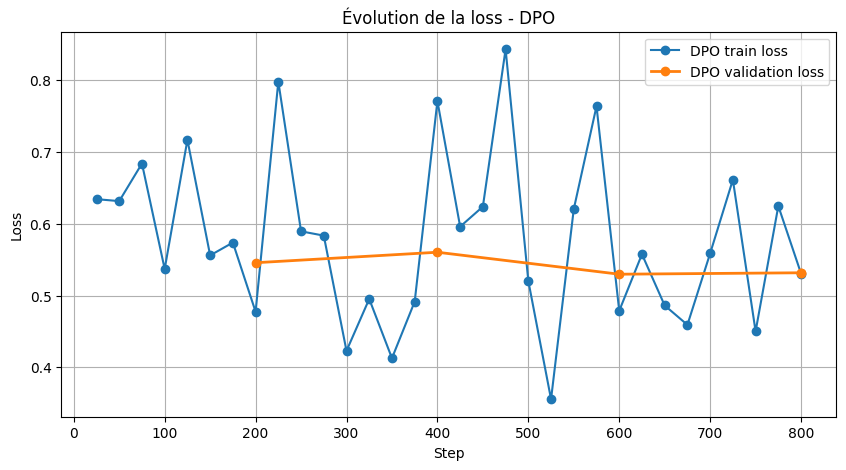

In [30]:
import matplotlib.pyplot as plt

train_logs = dpo_logs_df[dpo_logs_df["loss"].notna()]
eval_logs = dpo_logs_df[dpo_logs_df["eval_loss"].notna()]

plt.figure(figsize=(10, 5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="DPO train loss",
    marker="o"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    label="DPO validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Évolution de la loss - DPO")
plt.legend()
plt.grid(True)
plt.show()

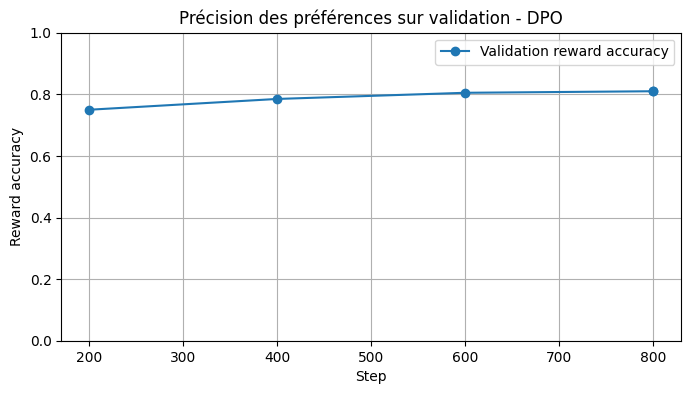

In [31]:
eval_reward_logs = dpo_logs_df[dpo_logs_df["eval_rewards/accuracies"].notna()]

plt.figure(figsize=(8, 4))

plt.plot(
    eval_reward_logs["step"],
    eval_reward_logs["eval_rewards/accuracies"],
    label="Validation reward accuracy",
    marker="o"
)

plt.xlabel("Step")
plt.ylabel("Reward accuracy")
plt.title("Précision des préférences sur validation - DPO")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [32]:
dpo_logs_path = f"{OUTPUT_DIR}/dpo_training_logs.csv"
dpo_logs_df.to_csv(dpo_logs_path, index=False)

print("Logs DPO sauvegardés :", dpo_logs_path)

Logs DPO sauvegardés : /content/qwen3-dpo/dpo_training_logs.csv


## Résultats du DPO

L'entraînement DPO a été réalisé à partir du meilleur checkpoint SFT sélectionné :

`outputs/qwen3-sft-3epochs/checkpoint-4762`

Le run DPO a été effectué sur 1 époque pour limiter le risque de sur-alignement et le coût GPU, tout en validant l'étape d'alignement par préférences demandée dans le projet.

| Métrique | Valeur |
|---|---:|
| Train loss | 0.5783 |
| Validation loss | 0.5317 |
| Global step | 800 |
| Epoch | 1 |
| Durée | ~48 min 44 |
| Validation reward accuracy | 0.81 |
| Validation reward margin | 1.696 |

La validation loss est légèrement inférieure à la train loss, ce qui ne montre pas de signe évident de sur-apprentissage sur ce run court.

La métrique 'reward accuracy' atteint environ 0.81.  
Cela signifie que le modèle attribue plus souvent un meilleur score aux réponses préférées qu'aux réponses rejetées sur le jeu de validation DPO.

Ce run valide l'étape d'alignement par préférences :
- chargement du checkpoint SFT retenu ;
- utilisation des paires `chosen/rejected` ;
- entraînement DPO avec TRL ;
- suivi des métriques ;
- sauvegarde d'un checkpoint DPO reproductible.

Le checkpoint DPO est conservé dans :

`/content/qwen3-dpo`

Pour l'intégration au projet local, ce dossier doit être téléchargé puis placé dans :

`outputs/qwen3-dpo`

## Évaluation finale DPO sur le jeu de test

Cette section évalue le checkpoint DPO sauvegardé sur le fichier `dpo_test.jsonl`.

Le test set n’a pas été utilisé pendant l’entraînement DPO ni pendant le suivi validation. Il sert à mesurer la capacité du modèle aligné à préférer les réponses `chosen` sur des paires jamais vues.


In [ ]:
from google.colab import files

# Uploader le fichier dpo_test.jsonl généré dans build_datasets.ipynb
uploaded = files.upload()


In [ ]:
DPO_TEST_FILE = "/content/dpo_test.jsonl"

dpo_test = load_dataset(
    "json",
    data_files=DPO_TEST_FILE,
    split="train"
)

dpo_test = dpo_test.map(
    format_for_dpo,
    remove_columns=dpo_test.column_names
)

print("DPO test :", len(dpo_test))
print(dpo_test[0])


In [ ]:
dpo_test_metrics = dpo_trainer.evaluate(
    eval_dataset=dpo_test,
    metric_key_prefix="test"
)

dpo_test_metrics["test_num_examples"] = len(dpo_test)
dpo_test_metrics


In [ ]:
import json
import pandas as pd

dpo_test_metrics_path = f"{OUTPUT_DIR}/dpo_test_metrics.json"
dpo_test_logs_path = f"{OUTPUT_DIR}/dpo_test_logs.csv"

with open(dpo_test_metrics_path, "w", encoding="utf-8") as f:
    json.dump(dpo_test_metrics, f, indent=2, ensure_ascii=False)

pd.DataFrame(dpo_trainer.state.log_history).to_csv(
    dpo_test_logs_path,
    index=False
)

print("Métriques DPO test sauvegardées :", dpo_test_metrics_path)
print("Logs DPO test sauvegardés :", dpo_test_logs_path)


### Interprétation attendue

Les métriques à reporter sont principalement :

- `test_loss` ;
- `test_rewards/accuracies` ;
- `test_rewards/margins` ;
- `test_num_examples`.

La métrique `test_rewards/accuracies` indique la proportion de paires de test pour lesquelles le modèle attribue un meilleur score à la réponse préférée qu’à la réponse rejetée.


In [33]:
!zip -r /content/qwen3-dpo.zip /content/qwen3-dpo

  adding: content/qwen3-dpo/ (stored 0%)
  adding: content/qwen3-dpo/ref/ (stored 0%)
  adding: content/qwen3-dpo/ref/adapter_model.safetensors (deflated 7%)
  adding: content/qwen3-dpo/ref/adapter_config.json (deflated 58%)
  adding: content/qwen3-dpo/tokenizer.json (deflated 81%)
  adding: content/qwen3-dpo/tokenizer_config.json (deflated 59%)
  adding: content/qwen3-dpo/adapter_model.safetensors (deflated 7%)
  adding: content/qwen3-dpo/checkpoint-600/ (stored 0%)
  adding: content/qwen3-dpo/checkpoint-600/ref/ (stored 0%)
  adding: content/qwen3-dpo/checkpoint-600/ref/adapter_model.safetensors (deflated 7%)
  adding: content/qwen3-dpo/checkpoint-600/ref/adapter_config.json (deflated 58%)
  adding: content/qwen3-dpo/checkpoint-600/tokenizer.json (deflated 81%)
  adding: content/qwen3-dpo/checkpoint-600/scheduler.pt (deflated 61%)
  adding: content/qwen3-dpo/checkpoint-600/tokenizer_config.json (deflated 59%)
  adding: content/qwen3-dpo/checkpoint-600/optimizer.pt (deflated 8%)
  add

In [34]:
from google.colab import files
files.download("/content/qwen3-dpo.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>